# Tutorial 05: Giải thích mô hình với SHAP (eXplainable AI)
> Mục tiêu: Dùng công cụ SHAP để "mở hộp đen" mô hình Random Forest, giải thích tại sao mô hình lại chẩn đoán hỏng hóc, từ đó đưa ra quyết định bảo trì cho kỹ sư.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import os

SEED = 42
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 100, 'font.size': 12})
print("Thư viện đã sẵn sàng!")


Thư viện đã sẵn sàng!


## 1. Trực giác về giá trị Shapley (Shapley Value)

SHAP dựa trên lý thuyết trò chơi. Tưởng tượng:
- 3 kỹ sư (A, B, C) cùng làm dự án được thưởng 100 triệu.
- SHAP value = Số tiền chia công bằng cho mỗi người dựa trên đóng góp thực tế của họ (thử mọi tổ hợp A làm một mình, A+B, A+C, v.v.)

Trong Machine Learning:
- **Dự án** = Một dự đoán của mô hình (ví dụ: xác suất lỗi IR là 90%).
- **Kỹ sư** = Các đặc trưng (RMS, Kurtosis, Band Energy, ...).
- **Phần thưởng cơ bản (Base Value)** = Xác suất trung bình nếu không biết thông tin gì (ví dụ: 25%).
- **SHAP value** = "Kỹ sư" (feature) này đã đóng góp bao nhiêu % để kéo xác suất từ 25% lên 90% (hoặc giảm xuống).


## 2. Chuẩn bị dữ liệu và huấn luyện lại Random Forest

Tương tự Tutorial 04, ta cần mô hình đã huấn luyện.


In [2]:
# Load dữ liệu từ Tutorial 03
if not (os.path.exists("X_features.csv") and os.path.exists("y_labels.csv")):
    raise FileNotFoundError("Chưa có file features. Vui lòng chạy Tutorial 03 trước!")

X_features = pd.read_csv("X_features.csv")
y_labels = pd.read_csv("y_labels.csv").iloc[:,0]

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
cls_names = list(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_enc, test_size=0.3, random_state=SEED, stratify=y_enc)

# Train RF
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)

# Tách scaler và model ra để tính SHAP
scaler = rf_pipe.named_steps['scaler']
rf_model = rf_pipe.named_steps['rf']

X_test_scaled = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_features.columns)

print(f"Test Accuracy: {rf_pipe.score(X_test, y_test):.2%}")


Test Accuracy: 96.16%


## 3. Tính toán SHAP values

Dùng `shap.TreeExplainer` (cực nhanh và tối ưu cho Random Forest / XGBoost).


In [3]:
print("⏳ Đang tính SHAP values...")
explainer = shap.TreeExplainer(rf_model)

# Tính cho 300 mẫu test để phân tích tổng quan
n_explain = 300
shap_values_raw = explainer.shap_values(X_test_df.iloc[:n_explain])

# Tiền xử lý format SHAP (tương thích các phiên bản thư viện SHAP mới/cũ)
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
else:
    # SHAP v0.42+ trả về mảng 3D: (n_samples, n_features, n_classes)
    shap_values = [np.array(shap_values_raw)[:, :, c] for c in range(shap_values_raw.shape[2])]

print(f"✅ Xong! Đã tính SHAP cho {len(shap_values)} lớp.")
print(f"Kích thước mỗi lớp: {shap_values[0].shape} (số mẫu x số đặc trưng)")


⏳ Đang tính SHAP values...
✅ Xong! Đã tính SHAP cho 4 lớp.
Kích thước mỗi lớp: (300, 19) (số mẫu x số đặc trưng)


## 4. SHAP Summary Plot – "Đặc trưng nào quyết định loại lỗi nào?"

Đây là biểu đồ quan trọng nhất của SHAP.

**Cách đọc:**
- Mỗi **chấm** = 1 mẫu (trong 300 mẫu đã test).
- **Trục dọc (Y)** = Các đặc trưng sắp xếp theo độ quan trọng.
- **Trục ngang (X)** = SHAP value. Nếu > 0: Đặc trưng này làm TĂNG xác suất của lớp đang xét.
- **Màu sắc** = Giá trị thực của đặc trưng (Đỏ = Cao, Xanh = Thấp).


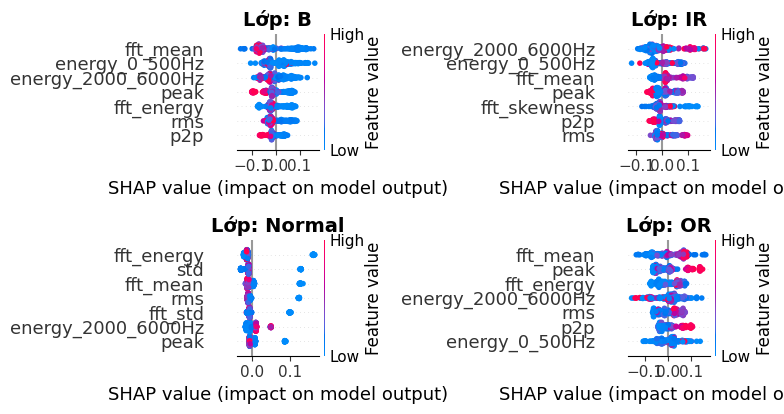


💡 VÍ DỤ CÁCH ĐỌC (Lớp IR - Rãnh trong):
- Xem dòng 'rms': Các chấm màu Đỏ (RMS cao) nằm tít bên PHẢI (SHAP > 0).
  -> Nghĩa là: Cứ thấy RMS cao thì xác suất bị lỗi Rãnh trong sẽ tăng lên mạnh.
- Ngược lại, nếu RMS thấp (chấm Xanh), nó nằm bên TRÁI (SHAP < 0) -> làm giảm xác suất lỗi IR.


In [4]:
n_classes = len(cls_names)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, cls in enumerate(cls_names):
    plt.sca(axes[idx])
    shap.summary_plot(shap_values[idx], X_test_df.iloc[:n_explain], show=False, max_display=7)
    plt.title(f'Lớp: {cls}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 VÍ DỤ CÁCH ĐỌC (Lớp IR - Rãnh trong):")
print("- Xem dòng 'rms': Các chấm màu Đỏ (RMS cao) nằm tít bên PHẢI (SHAP > 0).")
print("  -> Nghĩa là: Cứ thấy RMS cao thì xác suất bị lỗi Rãnh trong sẽ tăng lên mạnh.")
print("- Ngược lại, nếu RMS thấp (chấm Xanh), nó nằm bên TRÁI (SHAP < 0) -> làm giảm xác suất lỗi IR.")


## 5. SHAP Waterfall Plot – Giải phẫu 1 quyết định cụ thể

Nếu Summary Plot là góc nhìn vĩ mô (trên toàn bộ dữ liệu test), thì Waterfall Plot là góc nhìn vi mô (giải thích cho **chính xác 1 mẫu dữ liệu cụ thể**).

Câu hỏi: *"Tại sao hệ thống lại báo động là vòng bi số 123 bị lỗi rãnh ngoài (OR) vào lúc 10h sáng nay?"*


Mẫu số 0
Nhãn thật: OR | Dự đoán: OR


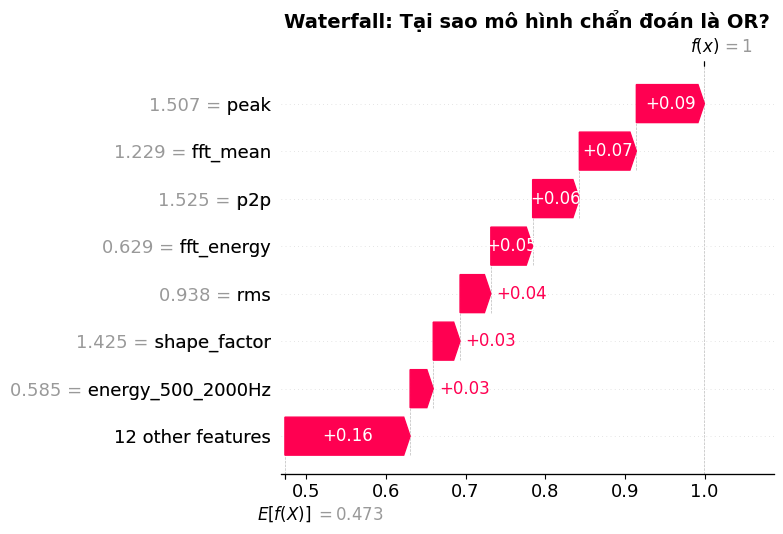


💡 CÁCH ĐỌC:
1. Khởi điểm: Trục hoành dưới cùng E[f(x)] = 0.473. Đây là xác suất gốc trung bình.
2. Thanh màu ĐỎ đẩy giá trị sang PHẢI (làm tăng xác suất bị OR).
3. Thanh màu XANH kéo giá trị sang TRÁI (làm giảm xác suất bị OR).
4. Kết quả cuối: f(x) = 1.000 (xác suất mô hình chốt lại).


In [5]:
# Chọn 1 mẫu bị lỗi rãnh ngoài (OR) mà mô hình đã dự đoán đúng
or_idx = cls_names.index('OR')
# Tìm mẫu đầu tiên trong X_test thuộc lớp OR
sample_idx = np.where(y_test[:n_explain] == or_idx)[0][0]

print(f"Mẫu số {sample_idx}")
print(f"Nhãn thật: OR | Dự đoán: {cls_names[rf_model.predict(X_test_scaled[[sample_idx]])[0]]}")

# Xử lý expected_value để phù hợp mọi version SHAP
base_val = explainer.expected_value[or_idx] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

# Tạo Explanation object
exp = shap.Explanation(
    values=shap_values[or_idx][sample_idx],
    base_values=base_val,
    data=X_test_df.iloc[sample_idx].values,
    feature_names=list(X_features.columns)
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(exp, show=False, max_display=8)
plt.title('Waterfall: Tại sao mô hình chẩn đoán là OR?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 CÁCH ĐỌC:")
print(f"1. Khởi điểm: Trục hoành dưới cùng E[f(x)] = {base_val:.3f}. Đây là xác suất gốc trung bình.")
print("2. Thanh màu ĐỎ đẩy giá trị sang PHẢI (làm tăng xác suất bị OR).")
print("3. Thanh màu XANH kéo giá trị sang TRÁI (làm giảm xác suất bị OR).")
print(f"4. Kết quả cuối: f(x) = {exp.values.sum() + base_val:.3f} (xác suất mô hình chốt lại).")


## 6. Từ SHAP đến Hành động bảo trì (Kết luận)

Làm sao kỹ sư nhà máy dùng SHAP để đưa ra quyết định?

| Kết quả SHAP | Gợi ý tình trạng vật lý | Khuyến nghị Hành động |
|---|---|---|
| Mẫu bị báo lỗi IR/OR + **RMS cao (đỏ, SHAP > 0)** + **Peak/Crest Factor bình thường** | Rung tổng thể tăng, có thể do lỏng trục, mòn đều, hoặc cọ xát. Không thấy xung va chạm rõ rệt. | Lên lịch bảo dưỡng định kỳ gần nhất, siết chặt cơ cấu, kiểm tra bôi trơn. |
| Mẫu bị báo lỗi IR/OR + **Kurtosis cao (đỏ, SHAP > 0)** + **Peak cao** | Có xung va chạm chu kỳ sắc nét. Vết nứt/rỗ đã hình thành rõ trên bề mặt rãnh. | **Báo động vàng**. Lên kế hoạch thay thế vòng bi sớm. |
| Mẫu bị báo lỗi + **energy_500_2000Hz (hoặc dải tần chứa BPFI/BPFO) màu Đỏ, SHAP rất cao** | Năng lượng tập trung mạnh vào tần số lỗi của cấu trúc ổ lăn. Chẩn đoán chính xác cao. | **Xác nhận hỏng hóc vật lý**. Có thể chỉ định chính xác là rãnh trong hay ngoài để chuẩn bị phụ tùng. |

---
## 📝 Bài tập

1. Thay vì chọn mẫu lỗi `OR`, hãy đổi mã ở mục 5 để vẽ Waterfall plot cho 1 mẫu **Bình thường (Normal)**. Xem đặc trưng nào giúp mô hình tin rằng nó bình thường.
2. Thử dùng `shap.Explainer` (Kernel Explainer) cho mô hình SVM ở Tutorial 04 xem tốc độ tính toán chậm hơn bao nhiêu so với TreeExplainer.

---
*Tutorial 05/05 – Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
